
# Prudential Life Insurance Assessment - Data Insights

This notebook gives every team member a faithful, pandas-native EDA walk-through of the Prudential Life Insurance Assessment training data (59,381 rows, 126 predictors + `Id` + ordinal `Response`). The flow mirrors the hygiene + profiling steps highlighted in the SAS 2017 paper, the 2023 Diva Portal thesis, and later 2024-2025 write-ups (missingness-first triage, categorical handling, duplicate/outlier scans, and ordinal-aware target views).

Sections:
- Feature inventory with semantics + detected data types so that everyone knows what each field encodes.
- Structural audit (shapes, dtypes, memory, duplicate checks) + target distribution sanity checks.
- Missingness analysis (per-column, per-row, correlation, and Response-segmented rates with 30%/50% drop recommendations).
- Cardinality profiling (object columns, binary/tiny-nunique numeric codes, and high-cardinality detectors).
- Continuous summaries, skew/kurtosis, and quantile-based outlier probes.
- Target relationship diagnostics (Spearman, grouped stats, crosstabs) + categorical highlights (`Product_Info_2`).
- Redundancy scans (highly correlated predictors) and pandas-native plots for histograms/boxplots/scatter.

Run the notebook from the project root (so `data/prudential-life-insurance-assessment/*.csv` resolves), and keep matplotlib installed if you want the optional plot cells at the end.



> **Usage notes**
> - All paths are relative to the project root. Start Jupyter/VS Code from there or update `DATA_DIR` below.
> - This notebook only relies on pandas + matplotlib (for the optional plotting cells). If `matplotlib` is missing, install it via `uv add matplotlib` or `pip install matplotlib` before running the last section.
> - Variables `ID_COL` and `TARGET` are defined up front and reused across cells to keep the checks deterministic.


In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from pandas.api import types as pdt

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda v: f"{v:0.4f}")

try:
    import matplotlib.pyplot as plt
except ImportError:  # matplotlib is only needed for the optional plotting cell
    plt = None
    print("matplotlib is not installed - skip the plotting section or install it to enable charts.")


In [ ]:
PROJECT_ROOT = (Path.cwd() / ".." / ".." / "..").resolve()
DATA_DIR = PROJECT_ROOT / "src" / "data" / "prudential-life-insurance-assessment"
TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"

ID_COL = "Id"
TARGET = "Response"

train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)
feature_columns = [c for c in train.columns if c not in (ID_COL, TARGET)]

print(f"Train shape: {train.shape} (rows, columns)")
print(f"Test shape:  {test.shape} (rows, columns)")
print(f"Detected {len(feature_columns)} modeling features (train columns minus Id/Response).")


FileNotFoundError: [Errno 2] No such file or directory: '/Users/tilmanhaferbeck/Library/CloudStorage/OneDrive-Persönlich/DeepLearning/data/prudential-life-insurance-assessment/train.csv'


## 1. Feature inventory (semantics + type hints)

Each Prudential feature is anonymized but the prefixes describe its semantic block (product, employment, insured info, insurance history, family history, medical history, or binary medical keywords). The table below combines:
- Canonical group + semantic short description.
- Pandas dtype + inferred modeling type (categorical, binary flag, or continuous numeric).
- Missing-rate buckets to align with the 30% (2023 thesis) and 50% (SAS 2017 / 2025 paper) drop heuristics.


In [3]:

prefix_templates = [
    ("Product_Info_", "Product characteristics", "Anonymized product attribute {suffix} describing the policy/product design."),
    ("Employment_Info_", "Employment and financial", "Derived employment or income feature {suffix} (normalized)."),
    ("InsuredInfo_", "Applicant demographics", "Anonymized insured attribute {suffix} (normalized)."),
    ("Insurance_History_", "Insurance history", "Underwriting or insurance history flag {suffix} (normalized code)."),
    ("Family_Hist_", "Family medical history", "Family-level medical history attribute {suffix} (binary/ordinal)."),
    ("Medical_History_", "Medical history", "Medical history attribute {suffix} (ordinal or scaled)."),
    ("Medical_Keyword_", "Medical keyword flags", "Binary medical keyword indicator {suffix} (0/1)."),
]

special_semantics = {
    ID_COL: ("Identifiers", "Unique application row identifier provided by Prudential."),
    TARGET: ("Target", "8-class ordinal risk response (1=lowest risk, 8=highest risk)."),
    "Ins_Age": ("Applicant demographics", "Normalized insured age (years)."),
    "Ht": ("Applicant biometrics", "Height in inches (min/max normalized to [0, 1])."),
    "Wt": ("Applicant biometrics", "Weight in pounds (normalized)."),
    "BMI": ("Applicant biometrics", "Body Mass Index derived from height/weight."),
    "Product_Info_2": ("Product characteristics", "Categorical product code (string - must be label encoded)."),
}


def describe_feature(col: str) -> tuple[str, str]:
    if col in special_semantics:
        return special_semantics[col]
    for prefix, group, template in prefix_templates:
        if col.startswith(prefix):
            suffix = col.replace(prefix, "")
            return group, template.format(suffix=suffix)
    return ("Other", "Additional anonymized attribute provided by Prudential.")


def infer_feature_type(series: pd.Series) -> str:
    if series.name == ID_COL:
        return "identifier (int)"
    if series.name == TARGET:
        return "ordinal target (int)"
    if pdt.is_string_dtype(series):
        return "categorical (string)"
    nunique = series.nunique(dropna=False)
    if nunique <= 2:
        return "binary flag (0/1)"
    if nunique <= 20:
        return "low-cardinality numeric code"
    return "continuous numeric"


def missing_band(rate: float) -> str:
    if rate >= 0.50:
        return ">=50% missing (drop candidate per SAS/2025 guidance)"
    if rate >= 0.30:
        return "30-50% missing (drop candidate per 2023 thesis)"
    if rate > 0:
        return "<30% missing (impute)"
    return "0% missing"

feature_records = []
for col in train.columns:
    group, meaning = describe_feature(col)
    series = train[col]
    miss_rate = float(series.isna().mean())
    feature_records.append({
        "feature": col,
        "group": group,
        "meaning": meaning,
        "dtype": str(series.dtype),
        "nunique": int(series.nunique(dropna=False)),
        "missing_rate": miss_rate,
        "missing_band": missing_band(miss_rate),
        "inferred_type": infer_feature_type(series),
    })

feature_overview = (
    pd.DataFrame(feature_records)
      .sort_values(["group", "feature"])
      .reset_index(drop=True)
)

print("Feature overview (scrollable - 128 rows covering Id/Response + 126 predictors):")
display(feature_overview)

print("Feature-group counts and average missingness:")
display(
    feature_overview
    .groupby("group")
    .agg(features=("feature", "count"), avg_missing=("missing_rate", "mean"))
    .sort_values("features", ascending=False)
)

print("Columns breaching the 30% and 50% missing thresholds:")
display(feature_overview.loc[feature_overview["missing_rate"] >= 0.30, ["feature", "missing_rate", "missing_band", "group"]])


Feature overview (scrollable - 128 rows covering Id/Response + 126 predictors):


,feature,group,meaning,dtype,nunique,missing_rate,missing_band,inferred_type
0,BMI,Applicant biometrics,Body Mass Index derived from height/weight.,float64,3256,0.0000,0% missing,continuous numeric
1,Ht,Applicant biometrics,"Height in inches (min/max normalized to [0, 1]).",float64,39,0.0000,0% missing,continuous numeric
2,Wt,Applicant biometrics,Weight in pounds (normalized).,float64,300,0.0000,0% missing,continuous numeric
3,Ins_Age,Applicant demographics,Normalized insured age (years).,float64,65,0.0000,0% missing,continuous numeric
4,InsuredInfo_1,Applicant demographics,Anonymized insured attribute 1 (normalized).,int64,3,0.0000,0% missing,low-cardinality numeric code
5,InsuredInfo_2,Applicant demographics,Anonymized insured attribute 2 (normalized).,int64,2,0.0000,0% missing,binary flag (0/1)
6,InsuredInfo_3,Applicant demographics,Anonymized insured attribute 3 (normalized).,int64,11,0.0000,0% missing,low-cardinality numeric code
7,InsuredInfo_4,Applicant demographics,Anonymized insured attribute 4 (normalized).,int64,2,0.0000,0% missing,binary flag (0/1)
8,InsuredInfo_5,Applicant demographics,Anonymized insured attribute 5 (normalized).,int64,2,0.0000,0% missing,binary flag (0/1)
9,InsuredInfo_6,Applicant demographics,Anonymized insured attribute 6 (normalized).,int64,2,0.0000,0% missing,binary flag (0/1)


Feature-group counts and average missingness:


,features,avg_missing
group,,
Medical keyword flags,48,0.0000
Medical history,41,0.0929
Applicant demographics,8,0.0000
Insurance history,8,0.0535
Product characteristics,7,0.0000
Employment and financial,6,0.0495
Family medical history,5,0.4173
Applicant biometrics,3,0.0000
Identifiers,1,0.0000


Columns breaching the 30% and 50% missing thresholds:


,feature,missing_rate,missing_band,group
18,Family_Hist_2,0.4826,30-50% missing (drop candidate per 2023 thesis),Family medical history
19,Family_Hist_3,0.5766,>=50% missing (drop candidate per SAS/2025 gui...,Family medical history
20,Family_Hist_4,0.3231,30-50% missing (drop candidate per 2023 thesis),Family medical history
21,Family_Hist_5,0.7041,>=50% missing (drop candidate per SAS/2025 gui...,Family medical history
27,Insurance_History_5,0.4277,30-50% missing (drop candidate per 2023 thesis),Insurance history
32,Medical_History_10,0.9906,>=50% missing (drop candidate per SAS/2025 gui...,Medical history
37,Medical_History_15,0.7510,>=50% missing (drop candidate per SAS/2025 gui...,Medical history
47,Medical_History_24,0.9360,>=50% missing (drop candidate per SAS/2025 gui...,Medical history
56,Medical_History_32,0.9814,>=50% missing (drop candidate per SAS/2025 gui...,Medical history


### Zero-heavy placeholders check

Some normalized numeric columns might encode missingness as literal zeros instead of `NaN`. Scan each numeric feature for its mean, missingness, and proportion of zero entries to flag columns where zeros dominate and could represent placeholder values. Adjust `zero_rate_threshold` below to focus on your preferred cutoff.


In [4]:
zero_rate_threshold = 0.50  # flag columns with >=50% zero entries
numeric_cols = train.select_dtypes(include=[np.number]).columns.difference([ID_COL, TARGET], sort=False)
zero_fill_candidates: list[dict] = []
for col in numeric_cols:
    series = train[col]
    zero_mask = series == 0
    zero_rate = float(zero_mask.mean())
    if zero_rate == 0 and float(series.isna().mean()) == 0:
        continue  # skip perfectly non-zero columns
    non_zero_mean = series.loc[~zero_mask]
    zero_fill_candidates.append({
        'feature': col,
        'dtype': str(series.dtype),
        'missing_rate': float(series.isna().mean()),
        'zero_rate': zero_rate,
        'mean': float(series.mean()),
        'non_zero_mean': float(non_zero_mean.mean()) if not non_zero_mean.empty else float('nan'),
    })
zero_fill_df = (
    pd.DataFrame(zero_fill_candidates)
      .sort_values('zero_rate', ascending=False)
      .assign(
          missing_rate=lambda df: df['missing_rate'].round(4),
          zero_rate=lambda df: df['zero_rate'].round(4),
          mean=lambda df: df['mean'].round(4),
          non_zero_mean=lambda df: df['non_zero_mean'].round(4),
      )
)
print(f'Numeric features sorted by zero prevalence (>= {zero_rate_threshold:.0%} shown first):')
display(
    zero_fill_df.loc[zero_fill_df['zero_rate'] >= zero_rate_threshold]
)
if (zero_fill_df['zero_rate'] >= zero_rate_threshold).sum() == 0:
    print('No numeric columns cross the zero-rate threshold; consider lowering zero_rate_threshold.')


Numeric features sorted by zero prevalence (>= 50% shown first):


,feature,dtype,missing_rate,zero_rate,mean,non_zero_mean
30,Medical_Keyword_13,int64,0.0000,0.9940,0.0060,1.0000
26,Medical_Keyword_9,int64,0.0000,0.9933,0.0067,1.0000
55,Medical_Keyword_38,int64,0.0000,0.9932,0.0068,1.0000
52,Medical_Keyword_35,int64,0.0000,0.9931,0.0069,1.0000
35,Medical_Keyword_18,int64,0.0000,0.9925,0.0075,1.0000
61,Medical_Keyword_44,int64,0.0000,0.9925,0.0075,1.0000
31,Medical_Keyword_14,int64,0.0000,0.9922,0.0078,1.0000
37,Medical_Keyword_20,int64,0.0000,0.9919,0.0081,1.0000
63,Medical_Keyword_46,int64,0.0000,0.9915,0.0085,1.0000
22,Medical_Keyword_5,int64,0.0000,0.9914,0.0086,1.0000


Further investigation about the feature with the highest missing values rate:

In [5]:
rows_with_mh10 = train.loc[train["Medical_History_10"].notna()]
print(rows_with_mh10["Medical_History_10"].describe())
rows_with_mh10

count   557.0000
mean    141.1185
std     107.7596
min       0.0000
25%       8.0000
50%     229.0000
75%     240.0000
max     240.0000
Name: Medical_History_10, dtype: float64


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,BMI,Employment_Info_1,Employment_Info_2,Employment_Info_3,Employment_Info_4,Employment_Info_5,Employment_Info_6,InsuredInfo_1,InsuredInfo_2,InsuredInfo_3,InsuredInfo_4,InsuredInfo_5,InsuredInfo_6,InsuredInfo_7,Insurance_History_1,Insurance_History_2,Insurance_History_3,Insurance_History_4,Insurance_History_5,Insurance_History_7,Insurance_History_8,Insurance_History_9,Family_Hist_1,Family_Hist_2,Family_Hist_3,Family_Hist_4,Family_Hist_5,Medical_History_1,Medical_History_2,Medical_History_3,Medical_History_4,Medical_History_5,Medical_History_6,Medical_History_7,Medical_History_8,Medical_History_9,Medical_History_10,Medical_History_11,Medical_History_12,Medical_History_13,Medical_History_14,Medical_History_15,Medical_History_16,Medical_History_17,Medical_History_18,Medical_History_19,Medical_History_20,Medical_History_21,Medical_History_22,Medical_History_23,Medical_History_24,Medical_History_25,Medical_History_26,Medical_History_27,Medical_History_28,Medical_History_29,Medical_History_30,Medical_History_31,Medical_History_32,Medical_History_33,Medical_History_34,Medical_History_35,Medical_History_36,Medical_History_37,Medical_History_38,Medical_History_39,Medical_History_40,Medical_History_41,Medical_Keyword_1,Medical_Keyword_2,Medical_Keyword_3,Medical_Keyword_4,Medical_Keyword_5,Medical_Keyword_6,Medical_Keyword_7,Medical_Keyword_8,Medical_Keyword_9,Medical_Keyword_10,Medical_Keyword_11,Medical_Keyword_12,Medical_Keyword_13,Medical_Keyword_14,Medical_Keyword_15,Medical_Keyword_16,Medical_Keyword_17,Medical_Keyword_18,Medical_Keyword_19,Medical_Keyword_20,Medical_Keyword_21,Medical_Keyword_22,Medical_Keyword_23,Medical_Keyword_24,Medical_Keyword_25,Medical_Keyword_26,Medical_Keyword_27,Medical_Keyword_28,Medical_Keyword_29,Medical_Keyword_30,Medical_Keyword_31,Medical_Keyword_32,Medical_Keyword_33,Medical_Keyword_34,Medical_Keyword_35,Medical_Keyword_36,Medical_Keyword_37,Medical_Keyword_38,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
159,218,1,A8,26,0.0769,2,1,1,0.7463,0.7818,0.3243,0.4498,0.0000,1,3,0.0650,2,0.7000,1,2,3,3,1,1,1,2,1,3,1,0.0000,1,3,2,2,NaN,0.4804,NaN,0.4554,3.0000,491,3,1,1,3,2,2,2,240.0000,3,2,3,3,240.0000,3,3,1,1,2,1,2,1,240.0000,1,3,3,1,1,2,3,NaN,3,3,1,2,2,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1
190,257,1,D1,26,0.1795,2,1,1,0.0896,0.6545,0.2573,0.4673,0.0370,9,1,0.0000,2,NaN,1,2,6,3,1,2,1,2,1,1,3,NaN,3,2,3,2,NaN,NaN,0.1268,NaN,10.0000,280,2,1,1,3,2,2,1,8.0000,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,3,1,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,8
698,946,1,D1,26,1.0000,2,1,1,0.5821,0.7091,0.2887,0.4652,0.3000,9,1,0.0000,2,1.0000,2,2,11,3,1,1,1,1,1,3,1,0.0133,1,1,2,2,0.6667,NaN,0.6056,NaN,3.0000,16,2,1,1,3,2,3,2,115.0000,3,3,1,1,NaN,3,3,1,1,2,2,2,3,NaN,1,3,3,1,1,2,3,NaN,3,3,1,2,2,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,8
832,1119,1,D1,26,0.4872,2,3,1,0.6119,0.7636,0.2845,0.4051,0.1800,12,1,0.0000,2,1.0000,1,2,8,3,1,1,1,2,1,3,1,0.0033,1,3,2,3,NaN,0.6373,NaN,0.5714,3.0000,161,2,1,1,3,2,2,2,1.0000,3,2,3,3,NaN,3,3,1,1,2,1,2,3,NaN,2,2,3,1,1,2,3,NaN,3,3,1,3,2,1,3,3,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,6
934,1255,1,B2,26,0.2308,2,3,1,0.2985,0.7636,0.3201,0.4611,0.1050,15,1,0.0000,2,0.2500,1,2,8,3,1,1,1,2,1,3,1,0.0010,1,3,2,3,0.3913,NaN,0.3380,NaN,3.0000,14,2,1,1,3,2,2,1,183.0000,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,1,3,3,1,1,2,3,NaN,1,3,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
...,...,...,...,...,...,...,...,...,...


## 2. Structural audit & hygiene checks

Confirm shapes, row/column counts, dtypes, memory footprint, and duplicates before going deeper. These are the same sanity checks referenced in the SAS + Diva Portal reports.


In [6]:

structure = pd.DataFrame(
    {
        "dataset": ["train", "test"],
        "rows": [len(train), len(test)],
        "columns": [train.shape[1], test.shape[1]],
        "memory_mb": [train.memory_usage(deep=True).sum() / (1024 ** 2), test.memory_usage(deep=True).sum() / (1024 ** 2)],
    }
)
structure["feature_columns_minus_id"] = [train.shape[1] - 2, test.shape[1] - 1]
structure["target_present"] = [True, False]
structure


,dataset,rows,columns,memory_mb,feature_columns_minus_id,target_present
0,train,59381,128,60.8775,126,True
1,test,19765,127,20.1124,126,False


In [7]:

print("Train head (first 3 rows):")
display(train.head(3))


Train head (first 3 rows):


,Id,Product_Info_1,Product_Info_2,Product_Info_3,Product_Info_4,Product_Info_5,Product_Info_6,Product_Info_7,Ins_Age,Ht,Wt,BMI,Employment_Info_1,Employment_Info_2,Employment_Info_3,Employment_Info_4,Employment_Info_5,Employment_Info_6,InsuredInfo_1,InsuredInfo_2,InsuredInfo_3,InsuredInfo_4,InsuredInfo_5,InsuredInfo_6,InsuredInfo_7,Insurance_History_1,Insurance_History_2,Insurance_History_3,Insurance_History_4,Insurance_History_5,Insurance_History_7,Insurance_History_8,Insurance_History_9,Family_Hist_1,Family_Hist_2,Family_Hist_3,Family_Hist_4,Family_Hist_5,Medical_History_1,Medical_History_2,Medical_History_3,Medical_History_4,Medical_History_5,Medical_History_6,Medical_History_7,Medical_History_8,Medical_History_9,Medical_History_10,Medical_History_11,Medical_History_12,Medical_History_13,Medical_History_14,Medical_History_15,Medical_History_16,Medical_History_17,Medical_History_18,Medical_History_19,Medical_History_20,Medical_History_21,Medical_History_22,Medical_History_23,Medical_History_24,Medical_History_25,Medical_History_26,Medical_History_27,Medical_History_28,Medical_History_29,Medical_History_30,Medical_History_31,Medical_History_32,Medical_History_33,Medical_History_34,Medical_History_35,Medical_History_36,Medical_History_37,Medical_History_38,Medical_History_39,Medical_History_40,Medical_History_41,Medical_Keyword_1,Medical_Keyword_2,Medical_Keyword_3,Medical_Keyword_4,Medical_Keyword_5,Medical_Keyword_6,Medical_Keyword_7,Medical_Keyword_8,Medical_Keyword_9,Medical_Keyword_10,Medical_Keyword_11,Medical_Keyword_12,Medical_Keyword_13,Medical_Keyword_14,Medical_Keyword_15,Medical_Keyword_16,Medical_Keyword_17,Medical_Keyword_18,Medical_Keyword_19,Medical_Keyword_20,Medical_Keyword_21,Medical_Keyword_22,Medical_Keyword_23,Medical_Keyword_24,Medical_Keyword_25,Medical_Keyword_26,Medical_Keyword_27,Medical_Keyword_28,Medical_Keyword_29,Medical_Keyword_30,Medical_Keyword_31,Medical_Keyword_32,Medical_Keyword_33,Medical_Keyword_34,Medical_Keyword_35,Medical_Keyword_36,Medical_Keyword_37,Medical_Keyword_38,Medical_Keyword_39,Medical_Keyword_40,Medical_Keyword_41,Medical_Keyword_42,Medical_Keyword_43,Medical_Keyword_44,Medical_Keyword_45,Medical_Keyword_46,Medical_Keyword_47,Medical_Keyword_48,Response
0,2,1,D3,10,0.0769,2,1,1,0.6418,0.5818,0.1485,0.3230,0.0280,12,1,0.0000,3,NaN,1,2,6,3,1,2,1,1,1,3,1,0.0007,1,1,2,2,NaN,0.5980,NaN,0.5268,4.0000,112,2,1,1,3,2,2,1,NaN,3,2,3,3,240.0000,3,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,1,3,1,2,2,1,3,3,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8
1,5,1,A1,26,0.0769,2,3,1,0.0597,0.6000,0.1318,0.2723,0.0000,1,3,0.0000,2,0.0018,1,2,6,3,1,2,1,2,1,3,1,0.0001,1,3,2,2,0.1884,NaN,0.0845,NaN,5.0000,412,2,1,1,3,2,2,1,NaN,3,2,3,3,0.0000,1,3,1,1,2,1,2,3,NaN,1,3,3,1,3,2,3,NaN,3,1,1,2,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,4
2,6,1,E1,26,0.0769,2,3,1,0.0299,0.7455,0.2887,0.4288,0.0300,9,1,0.0000,2,0.0300,1,2,8,3,1,1,1,2,1,1,3,NaN,3,2,3,3,0.3043,NaN,0.2254,NaN,10.0000,3,2,2,1,3,2,2,2,NaN,3,2,3,3,NaN,1,3,1,1,2,1,2,3,NaN,2,2,3,1,3,2,3,NaN,3,3,1,3,2,1,3,3,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,8


In [8]:
print("train.info():")
train.info(show_counts=True)

train.info():
<class 'pandas.DataFrame'>
RangeIndex: 59381 entries, 0 to 59380
Columns: 128 entries, Id to Response
dtypes: float64(18), int64(109), str(1)
memory usage: 58.0 MB


In [9]:
print("Column dtype counts:")
display(train.dtypes.value_counts().to_frame(name="column_count"))

print("Top 20 columns by memory usage (bytes, deep=True):")
display(
    train.memory_usage(deep=True)
         .sort_values(ascending=False)
         .head(20)
         .to_frame(name="bytes")
)

Column dtype counts:


,column_count
int64,109
float64,18
str,1


Top 20 columns by memory usage (bytes, deep=True):


,bytes
Product_Info_2,3503479
Medical_History_26,475048
Medical_Keyword_10,475048
Medical_Keyword_4,475048
Medical_Keyword_5,475048
Medical_Keyword_6,475048
Medical_Keyword_7,475048
Medical_Keyword_8,475048
Medical_Keyword_9,475048
Medical_Keyword_11,475048


In [10]:

duplicate_stats = pd.Series(
    {
        "duplicate_rows": int(train.duplicated().sum()),
        "duplicate_ids": int(train[ID_COL].duplicated().sum()),
        "id_is_unique": bool(train[ID_COL].is_unique),
    }
)
print("Duplicate summary:")
display(duplicate_stats.to_frame(name="value"))


Duplicate summary:


,value
duplicate_rows,0
duplicate_ids,0
id_is_unique,True



## 3. Target (`Response`) distribution (ordinal sanity check)

Check imbalance, gaps, and ordinal coverage. Later modeling work (per 2024 analyses) often benefits from calibration/ordinal treatment, so understanding the base distribution matters.


In [11]:

response_counts = train[TARGET].value_counts().sort_index()
response_df = pd.DataFrame(
    {
        "count": response_counts,
        "percent": response_counts / response_counts.sum(),
    }
)

print("Response distribution (counts + proportions):")
display(response_df)

print("Response describe():")
display(train[TARGET].describe())

print("Unique Response levels (sorted):", sorted(train[TARGET].unique()))


Response distribution (counts + proportions):


,count,percent
Response,,
1,6207,0.1045
2,6552,0.1103
3,1013,0.0171
4,1428,0.0240
5,5432,0.0915
6,11233,0.1892
7,8027,0.1352
8,19489,0.3282


Response describe():


count   59381.0000
mean        5.6368
std         2.4568
min         1.0000
25%         4.0000
50%         6.0000
75%         8.0000
max         8.0000
Name: Response, dtype: float64

Unique Response levels (sorted): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]



## 4. Missingness profiling (column, row, correlation, Response segments)

Structured missingness is one of the defining characteristics of this dataset. These cells quantify column-level rates, row-level burden, correlations between missing patterns, and per-Response missing profiles. Outputs also flag columns breaching the 30%/50% drop thresholds that multiple papers use.


In [12]:

feature_missing = (
    train[feature_columns]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .to_frame(name="missing_rate")
)
feature_missing["missing_count"] = (feature_missing["missing_rate"] * len(train)).astype(int)
feature_missing["missing_band"] = feature_missing["missing_rate"].apply(missing_band)

print("Top 25 columns by missing rate:")
display(feature_missing.head(25))

print("Missing-rate summary stats:")
display(feature_missing.describe())

missing_30 = feature_missing.loc[feature_missing["missing_rate"] > 0.30].index.tolist()
missing_50 = feature_missing.loc[feature_missing["missing_rate"] > 0.50].index.tolist()
print(f"Columns >30% missing (len={len(missing_30)}):", missing_30)
print(f"Columns >50% missing (len={len(missing_50)}):", missing_50)


Top 25 columns by missing rate:


,missing_rate,missing_count,missing_band
Medical_History_10,0.9906,58824,>=50% missing (drop candidate per SAS/2025 gui...
Medical_History_32,0.9814,58274,>=50% missing (drop candidate per SAS/2025 gui...
Medical_History_24,0.9360,55580,>=50% missing (drop candidate per SAS/2025 gui...
Medical_History_15,0.7510,44596,>=50% missing (drop candidate per SAS/2025 gui...
Family_Hist_5,0.7041,41811,>=50% missing (drop candidate per SAS/2025 gui...
Family_Hist_3,0.5766,34241,>=50% missing (drop candidate per SAS/2025 gui...
Family_Hist_2,0.4826,28656,30-50% missing (drop candidate per 2023 thesis)
Insurance_History_5,0.4277,25396,30-50% missing (drop candidate per 2023 thesis)
Family_Hist_4,0.3231,19184,30-50% missing (drop candidate per 2023 thesis)
Employment_Info_6,0.1828,10854,<30% missing (impute)


Missing-rate summary stats:


,missing_rate,missing_count
count,126.0000,126.0000
mean,0.0525,3119.8651
std,0.1888,11208.9846
min,0.0000,0.0000
25%,0.0000,0.0000
50%,0.0000,0.0000
75%,0.0000,0.0000
max,0.9906,58824.0000


Columns >30% missing (len=9): ['Medical_History_10', 'Medical_History_32', 'Medical_History_24', 'Medical_History_15', 'Family_Hist_5', 'Family_Hist_3', 'Family_Hist_2', 'Insurance_History_5', 'Family_Hist_4']
Columns >50% missing (len=6): ['Medical_History_10', 'Medical_History_32', 'Medical_History_24', 'Medical_History_15', 'Family_Hist_5', 'Family_Hist_3']


In [13]:

row_missing = train.isna().sum(axis=1)
print("Row-wise missing count distribution:")
display(row_missing.describe())
print("Most common row missing-count values:")
display(row_missing.value_counts().head(20))


Row-wise missing count distribution:


count   59381.0000
mean        6.6200
std         1.0828
min         2.0000
25%         6.0000
50%         7.0000
75%         7.0000
max        12.0000
dtype: float64

Most common row missing-count values:


6     20637
7     19699
8      8994
5      6521
9      2103
4       925
10      338
3       116
11       40
2         6
12        2
Name: count, dtype: int64

In [14]:

missing_by_response = train.groupby(TARGET)[feature_columns].apply(lambda frame: frame.isna().mean())
missing_signal = missing_by_response.mean(axis=0).sort_values(ascending=False).head(25)

print("Average missing rate per feature when averaged across Response classes (top 25):")
display(missing_signal.to_frame(name="mean_missing_rate"))

print("Missing rates by Response class (subset of top-missing columns):")
display(missing_by_response[missing_signal.index].round(3))


Average missing rate per feature when averaged across Response classes (top 25):


,mean_missing_rate
Medical_History_10,0.9899
Medical_History_32,0.9720
Medical_History_24,0.9290
Family_Hist_5,0.6894
Medical_History_15,0.5910
Family_Hist_3,0.5635
Family_Hist_2,0.5029
Insurance_History_5,0.4477
Family_Hist_4,0.3414
Employment_Info_6,0.1943


Missing rates by Response class (subset of top-missing columns):


,Medical_History_10,Medical_History_32,Medical_History_24,Family_Hist_5,Medical_History_15,Family_Hist_3,Family_Hist_2,Insurance_History_5,Family_Hist_4,Employment_Info_6,Medical_History_1,Employment_Info_4,Employment_Info_1,Medical_Keyword_13,Medical_Keyword_45,Medical_Keyword_7,Medical_Keyword_14,Medical_Keyword_12,Medical_Keyword_11,Medical_Keyword_10,Medical_Keyword_9,Medical_Keyword_15,Medical_Keyword_46,Medical_Keyword_8,Medical_Keyword_5
Response,,,,,,,,,,,,,,,,,,,,,,,,,
1,0.9840,0.9760,0.9270,0.5430,0.6410,0.4360,0.6520,0.4590,0.4990,0.1890,0.1120,0.1270,0.0030,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9870,0.9790,0.9180,0.6130,0.6900,0.4730,0.5940,0.4140,0.4190,0.1820,0.1060,0.1040,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9900,0.9450,0.9160,0.7350,0.1100,0.6030,0.4730,0.5580,0.2990,0.2170,0.2280,0.0840,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9940,0.9470,0.9290,0.7840,0.1080,0.6800,0.3860,0.5080,0.2490,0.2330,0.2180,0.1040,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9900,0.9830,0.9350,0.6810,0.7810,0.5630,0.5230,0.4370,0.3550,0.2250,0.1470,0.1030,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9830,0.9520,0.8940,0.6970,0.7250,0.5490,0.5010,0.3890,0.3280,0.1500,0.1550,0.1560,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9940,0.9970,0.9440,0.6500,0.8010,0.5070,0.5420,0.3610,0.3730,0.1700,0.1240,0.1100,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9970,0.9990,0.9670,0.8110,0.8730,0.6950,0.3520,0.4570,0.2090,0.1880,0.1760,0.0970,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000


In [37]:
missing_corr_matrix = train[feature_columns].isna().astype("int8").corr()
mask = np.triu(np.ones(missing_corr_matrix.shape, dtype=bool))
top_missing_pairs = (
    missing_corr_matrix
    .mask(mask)
    .stack()
    .sort_values(ascending=False)
    .head(20)
    .rename("missingness_corr")
    .to_frame()
)

print("Top missingness correlations (features that tend to be missing together):")
display(top_missing_pairs)


Top missingness correlations (features that tend to be missing together):


missingness_corr
Family_Hist_4       Family_Hist_2                  0.4511
Family_Hist_5       Family_Hist_3                  0.4345
Medical_History_24  Medical_History_10             0.1665
Family_Hist_3       Insurance_History_5            0.1628
Medical_History_1   Insurance_History_5            0.1472
Medical_History_32  Medical_History_15             0.1435
Family_Hist_5       Insurance_History_5            0.1414
Medical_History_1   Family_Hist_3                  0.1235
                    Family_Hist_5                  0.1085
Medical_History_24  Medical_History_15             0.1037
Medical_History_15  Family_Hist_3                  0.0887
                    Family_Hist_5                  0.0861
                    Medical_History_10             0.0676
Insurance_History_5 Employment_Info_6              0.0512
Medical_History_10  Family_Hist_5                  0.0460
Medical_History_24  Employment_Info_6              0.0416
Medical_History_32  Medical_History_24             0.0408
Medical_History_10  Family_Hist_3                  0.0390
Family_Hist_3       Employment_Info_6              0.0369
Medical_History_15  Insurance_History_5            0.0355


## 5. Cardinality scan & pseudo-categorical detection

Identify low-nunique numeric codes, binary flags, and genuinely continuous features. Recent JRSSB-style analyses emphasize the very high cardinality in some categorical groups, so we catalogue both extremes.


In [16]:

feature_nunique = train[feature_columns].nunique(dropna=False)
cardinality = feature_nunique.sort_values()

print("Lowest 20 features by unique values (near-constant/binary):")
display(cardinality.head(20).to_frame(name="nunique"))

print("Highest 20 features by unique values (high-cardinality):")
display(cardinality.tail(20).to_frame(name="nunique"))


Lowest 20 features by unique values (near-constant/binary):


,nunique
Product_Info_1,2
Medical_Keyword_20,2
Medical_Keyword_19,2
Medical_Keyword_18,2
Medical_Keyword_17,2
Medical_Keyword_16,2
Medical_Keyword_15,2
Medical_Keyword_14,2
Medical_Keyword_13,2
Medical_Keyword_12,2


Highest 20 features by unique values (high-cardinality):


,nunique
Employment_Info_2,36
Ht,39
Ins_Age,65
Family_Hist_2,69
Family_Hist_4,69
Family_Hist_3,91
Family_Hist_5,91
Medical_History_32,96
Medical_History_10,104
Medical_History_1,172


In [17]:

string_cols = train.select_dtypes(include=["string", "object"]).columns.drop([ID_COL, TARGET], errors="ignore")
numeric_cols = train.select_dtypes(include="number").columns.drop([ID_COL, TARGET], errors="ignore")

binary_cols = [col for col in numeric_cols if train[col].dropna().isin([0, 1]).all()]
cat_like_numeric = [col for col in numeric_cols if feature_nunique[col] <= 20]
cat_like_nonbinary = [col for col in cat_like_numeric if col not in binary_cols]
continuous_like = [col for col in numeric_cols if feature_nunique[col] > 20]

cardinality_summary = pd.DataFrame(
    {
        "category": ["string (object)", "binary numeric", "low-cardinality numeric (<=20 unique)", "continuous-like numeric (>20 unique)"],
        "count": [len(string_cols), len(binary_cols), len(cat_like_numeric), len(continuous_like)],
    }
)

print("Feature-type buckets:")
display(cardinality_summary)
print(f"String columns: {string_cols.tolist()}")


Feature-type buckets:


,category,count
0,string (object),1
1,binary numeric,48
2,low-cardinality numeric (<=20 unique),104
3,continuous-like numeric (>20 unique),21


String columns: ['Product_Info_2']


In [35]:
print(train["Product_Info_2"].describe())
train["Product_Info_2"].head(10)

count     59381
unique       19
top          D3
freq      14321
Name: Product_Info_2, dtype: object


0    D3
1    A1
2    E1
3    D4
4    D2
5    D2
6    A8
7    D2
8    D3
9    E1
Name: Product_Info_2, dtype: str

In [18]:

print("Object/string columns (value counts, top 15 levels):")
for col in string_cols:
    print(f"{col} value counts:")
    vc = train[col].value_counts(dropna=False).head(15)
    display(pd.DataFrame({"value": vc.index, "count": vc.values, "percent": vc.values / len(train)}))

print("Numeric features with <=20 unique values (showing first 15 columns and their top codes):")
for col in cat_like_numeric[:15]:
    vc = train[col].value_counts(dropna=False).head(10)
    display(pd.DataFrame({"value": vc.index, "count": vc.values, "percent": vc.values / len(train)}).assign(feature=col))


Object/string columns (value counts, top 15 levels):
Product_Info_2 value counts:


,value,count,percent
0,D3,14321,0.2412
1,D4,10812,0.1821
2,A8,6835,0.1151
3,D1,6554,0.1104
4,D2,6286,0.1059
5,E1,2647,0.0446
6,A1,2363,0.0398
7,A6,2098,0.0353
8,A2,1974,0.0332
9,A7,1383,0.0233


Numeric features with <=20 unique values (showing first 15 columns and their top codes):


,value,count,percent,feature
0,1,57816,0.9736,Product_Info_1
1,2,1565,0.0264,Product_Info_1


,value,count,percent,feature
0,2,58968,0.9930,Product_Info_5
1,3,413,0.0070,Product_Info_5


...

,value,count,percent,feature
0,1,58574,0.9864,InsuredInfo_5
1,3,807,0.0136,InsuredInfo_5


,value,count,percent,feature
0,1,35083,0.5908,InsuredInfo_6
1,2,24298,0.4092,InsuredInfo_6


,value,count,percent,feature
0,1,58237,0.9807,InsuredInfo_7
1,3,1144,0.0193,InsuredInfo_7


,value,count,percent,feature
0,2,43206,0.7276,Insurance_History_1
1,1,16175,0.2724,Insurance_History_1


,value,count,percent,feature
0,1,57724,0.9721,Insurance_History_2
1,3,1656,0.0279,Insurance_History_2
2,2,1,0.0000,Insurance_History_2



## 6. Continuous summaries, skew/kurtosis, and quantile-based outlier scan

Quantify central tendency, dispersion, skewness, and kurtosis for continuous-like features. The 2023 thesis uses skewness to decide between median vs. mean imputation; we replicate that logic below.


In [19]:

if continuous_like:
    cont_summary = (
        train[continuous_like]
        .describe(percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99])
        .T
        .sort_values("std", ascending=False)
    )
    print("Continuous feature summary stats (top 20 by std):")
    display(cont_summary.head(20))
else:
    print("No continuous-like numeric features detected.")


Continuous feature summary stats (top 20 by std):


,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
Medical_History_2,59381.0000,253.9871,178.6212,1.0000,3.0000,16.0000,57.0000,112.0000,162.0000,418.0000,491.0000,579.0000,628.0000,648.0000
Medical_History_10,557.0000,141.1185,107.7596,0.0000,0.0000,0.0000,0.0000,8.0000,229.0000,240.0000,240.0000,240.0000,240.0000,240.0000
Medical_History_15,14785.0000,123.7610,98.5162,0.0000,0.0000,0.0000,0.0000,17.0000,117.0000,240.0000,240.0000,240.0000,240.0000,240.0000
Medical_History_24,3801.0000,50.6356,78.1491,0.0000,0.0000,0.0000,0.0000,1.0000,8.0000,64.0000,229.0000,240.0000,240.0000,240.0000
Medical_History_32,1107.0000,11.9657,38.7188,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,2.0000,24.0000,85.8000,240.0000,240.0000
Medical_History_1,50492.0000,7.9622,13.0277,0.0000,0.0000,0.0000,1.0000,2.0000,4.0000,9.0000,18.0000,27.0000,63.0000,240.0000
Product_Info_3,59381.0000,24.4157,5.0729,1.0000,10.0000,10.0000,10.0000,26.0000,26.0000,26.0000,26.0000,26.0000,30.0000,38.0000
Employment_Info_2,59381.0000,8.6418,4.2271,1.0000,1.0000,1.0000,1.0000,9.0000,9.0000,9.0000,12.0000,14.0000,15.0000,38.0000
Employment_Info_6,48527.0000,0.3615,0.3496,0.0000,0.0000,0.0000,0.0050,0.0600,0.2500,0.5500,1.0000,1.0000,1.0000,1.0000
Product_Info_4,59381.0000,0.3290,0.2826,0.0000,0.0000,0.0769,0.0769,0.0769,0.2308,0.4872,0.8462,1.0000,1.0000,1.0000


In [20]:

if continuous_like:
    skewness = train[continuous_like].skew(numeric_only=True).sort_values(ascending=False)
    kurtosis = train[continuous_like].kurt(numeric_only=True).sort_values(ascending=False)

    median_fill_candidates = skewness[skewness.abs() > 1].index.tolist()
    mean_fill_candidates = skewness[skewness.abs() <= 1].index.tolist()

    print("Top 10 most positively skewed continuous features:")
    display(skewness.head(10).to_frame(name="skew"))
    print("Top 10 most negatively skewed continuous features:")
    display(skewness.tail(10).to_frame(name="skew"))

    print("Top 10 features by kurtosis (heavy tails):")
    display(kurtosis.head(10).to_frame(name="kurtosis"))

    print("Features suggested for median imputation (> |1| skew):", median_fill_candidates)
    print("Features suggested for mean imputation (<= |1| skew):", mean_fill_candidates[:15], "...")
else:
    print("No continuous-like numeric features detected.")


Top 10 most positively skewed continuous features:


,skew
Insurance_History_5,102.6198
Employment_Info_4,15.4799
Medical_History_1,5.6352
Employment_Info_1,4.7086
Medical_History_32,4.3428
Medical_History_24,1.5574
Product_Info_4,1.2213
BMI,0.9443
Employment_Info_6,0.7868
Wt,0.6940


Top 10 most negatively skewed continuous features:


,skew
Employment_Info_2,0.5635
Family_Hist_2,0.2121
Family_Hist_4,0.2071
Ins_Age,0.0220
Medical_History_15,0.0171
Ht,-0.0867
Medical_History_10,-0.3100
Family_Hist_3,-0.5683
Family_Hist_5,-0.7285
Product_Info_3,-2.3762


Top 10 features by kurtosis (heavy tails):


,kurtosis
Insurance_History_5,12359.5965
Employment_Info_4,362.1581
Medical_History_1,51.1349
Employment_Info_1,37.1300
Medical_History_32,19.7406
Employment_Info_2,6.4945
Product_Info_3,4.2738
BMI,1.4348
Medical_History_24,0.9684
Wt,0.9677


Features suggested for median imputation (> |1| skew): ['Insurance_History_5', 'Employment_Info_4', 'Medical_History_1', 'Employment_Info_1', 'Medical_History_32', 'Medical_History_24', 'Product_Info_4', 'Product_Info_3']
Features suggested for mean imputation (<= |1| skew): ['BMI', 'Employment_Info_6', 'Wt', 'Medical_History_2', 'Employment_Info_2', 'Family_Hist_2', 'Family_Hist_4', 'Ins_Age', 'Medical_History_15', 'Ht', 'Medical_History_10', 'Family_Hist_3', 'Family_Hist_5'] ...


In [21]:

if continuous_like:
    q01 = train[continuous_like].quantile(0.01)
    q99 = train[continuous_like].quantile(0.99)
    iqr = train[continuous_like].quantile(0.75) - train[continuous_like].quantile(0.25)
    quantile_bounds = pd.DataFrame({"q01": q01, "q99": q99, "iqr": iqr})
    quantile_bounds["range_q"] = quantile_bounds["q99"] - quantile_bounds["q01"]
    print("Features with the widest 1st-99th percentile range (top 15):")
    display(quantile_bounds.sort_values("range_q", ascending=False).head(15))
else:
    print("No continuous-like numeric features detected.")


Features with the widest 1st-99th percentile range (top 15):


,q01,q99,iqr,range_q
Medical_History_2,3.0000,628.0000,306.0000,625.0000
Medical_History_32,0.0000,240.0000,2.0000,240.0000
Medical_History_24,0.0000,240.0000,63.0000,240.0000
Medical_History_15,0.0000,240.0000,223.0000,240.0000
Medical_History_10,0.0000,240.0000,232.0000,240.0000
Medical_History_1,0.0000,63.0000,7.0000,63.0000
Product_Info_3,10.0000,30.0000,0.0000,20.0000
Employment_Info_2,1.0000,15.0000,0.0000,14.0000
Employment_Info_6,0.0000,1.0000,0.4900,1.0000
Product_Info_4,0.0000,1.0000,0.4103,1.0000



## 7. Relationship to `Response`

Evaluate how predictors move with the ordinal target via grouped stats, Spearman correlations (preferred for ordinal targets), categorical summaries, and binned crosstabs.


In [22]:

spearman = (
    train.drop(columns=[ID_COL])
    .corr(method="spearman", numeric_only=True)[TARGET]
    .drop(TARGET)
)
top_by_abs = spearman.abs().sort_values(ascending=False).head(10).index.tolist()

print("Grouped stats (mean/median/std) for features with strongest Spearman signal (top 10):")
response_group_summary = train.groupby(TARGET)[top_by_abs].agg(["mean", "median", "std"])
display(response_group_summary)


Grouped stats (mean/median/std) for features with strongest Spearman signal (top 10):


BMI                   Wt               Medical_History_15  \
           mean median    std   mean median    std               mean   
Response                                                                
1        0.5093 0.4832 0.1476 0.3200 0.3096 0.1027           117.2983   
2        0.5469 0.5106 0.1576 0.3433 0.3305 0.1075           126.1598   
3        0.5159 0.5106 0.1198 0.3229 0.3180 0.0863             7.4435   
4        0.4178 0.4197 0.0759 0.2613 0.2573 0.0649             9.1005   
5        0.5708 0.5918 0.1273 0.3511 0.3515 0.0938           148.0537   
6        0.4906 0.4897 0.0986 0.3131 0.3096 0.0739           127.9018   
7        0.4647 0.4708 0.0768 0.2915 0.2908 0.0655           171.0594   
8        0.3936 0.3949 0.0693 0.2398 0.2364 0.0604           181.6506   

                           Medical_History_23                \
           median      std               mean median    std   
Response                                                      
1         99.0000 102.5548             2.1255 3.0000 0.9922   
2        117.0000  99.6259             2.1676 3.0000 0.9859   
3          0.0000  31.7510             2.5301 3.0000 0.8483   
4          0.0000  31.5001             2.7451 3.0000 0.6672   
5        162.0000  86.5747             2.4194 3.0000 0.9079   
6        116.0000  92.6985             2.4632 3.0000 0.8863   
7        214.0000  77.8064             2.2970 3.0000 0.9549   
8        217.0000  66.5649             2.9245 3.0000 0.3813   

         Medical_Keyword_15               Medical_History_4                \
                       mean median    std              mean median    std   
Response                                                                    
1                    0.3606 0.0000 0.4802            1.5486 2.0000 0.4977   
2                    0.3254 0.0000 0.4686            1.5784 2.0000 0.4938   
3                    0.1885 0.0000 0.3913            1.0918 1.0000 0.2889   
4                    0.0973 0.0000 0.2965            1.0994 1.0000 0.2994   
5                    0.2515 0.0000 0.4339            1.6607 2.0000 0.4735   
6                    0.2234 0.0000 0.4166            1.4842 1.0000 0.4998   
7                    0.3098 0.0000 0.4625            1.7481 2.0000 0.4341   
8                    0.0127 0.0000 0.1119            1.8427 2.0000 0.3641   

         Product_Info_4               Medical_Keyword_3               Ins_Age  \
                   mean median    std              mean median    std    mean   
Response                                                                        
1                0.2533 0.1846 0.2513            0.1452 0.0000 0.3523  0.4929   
2                0.2495 0.2308 0.2447            0.1664 0.0000 0.3724  0.4610   
3                0.2142 0.1179 0.2334            0.0286 0.0000 0.1668  0.3595   
4                0.2566 0.2308 0.2305            0.0021 0.0000 0.0458  0.3370   
5                0.2471 0.1795 0.2621            0.0565 0.0000 0.2309  0.4046   
6                0.3394 0.2308 0.2774            0.0496 0.0000 0.2171  0.4263   
7                0.3490 0.2308 0.2802            0.0016 0.0000 0.0402  0.4345   
8                0.3996 0.2821 0.2973            0.0013 0.0000 0.0365  0.3430   

                       Medical_History_39                
         median    std               mean median    std  
Response                                                 
1        0.5224 0.2027             2.6274 3.0000 0.7787  
2        0.4776 0.1932             2.5739 3.0000 0.8190  
3        0.3582 0.1885             2.8875 3.0000 0.4611  
4        0.3284 0.1735             2.9468 3.0000 0.3220  
5        0.4030 0.2013             2.8041 3.0000 0.5945  
6        0.4328 0.1884             2.8182 3.0000 0.5749  
7        0.4478 0.1856             2.9325 3.0000 0.3612  
8        0.3134 0.1856             2.9431 3.0000 0.3325

In [23]:

spearman_df = pd.DataFrame({"spearman_corr": spearman}).sort_values("spearman_corr", ascending=False)
print("Top 20 positive Spearman correlations with Response:")
display(spearman_df.head(20))
print("Top 20 negative Spearman correlations with Response:")
display(spearman_df.tail(20))


Top 20 positive Spearman correlations with Response:


,spearman_corr
Medical_History_15,0.3125
Medical_History_23,0.3100
Medical_History_4,0.2816
Product_Info_4,0.2492
Medical_History_39,0.2080
Medical_History_1,0.1614
InsuredInfo_6,0.1607
Medical_History_6,0.1585
Insurance_History_5,0.1449
Medical_History_24,0.1285


Top 20 negative Spearman correlations with Response:


,spearman_corr
Medical_History_18,-0.0797
Medical_Keyword_42,-0.0863
InsuredInfo_5,-0.0876
Medical_Keyword_38,-0.0880
Medical_Keyword_1,-0.0905
InsuredInfo_7,-0.0914
Family_Hist_4,-0.0997
Employment_Info_3,-0.1013
Insurance_History_2,-0.1123
Medical_Keyword_25,-0.1150


In [24]:

if "Product_Info_2" in train.columns:
    print("Product_Info_2 summary (counts + Response mean/median):")
    product_info2_summary = (
        train.groupby("Product_Info_2")[TARGET]
        .agg(["count", "mean", "median"])
        .sort_values("count", ascending=False)
    )
    display(product_info2_summary.head(20))

    print("Tail of Product_Info_2 frequency distribution (rare levels):")
    display(train["Product_Info_2"].value_counts(normalize=True).sort_values().head(10).to_frame(name="percent"))


Product_Info_2 summary (counts + Response mean/median):


,count,mean,median
Product_Info_2,,,
D3,14321,5.5278,6.0000
D4,10812,6.3872,7.0000
A8,6835,5.3865,6.0000
D1,6554,4.6840,6.0000
D2,6286,5.2695,6.0000
E1,2647,6.1383,7.0000
A1,2363,6.1295,7.0000
A6,2098,6.8198,8.0000
A2,1974,5.4281,6.0000


Tail of Product_Info_2 frequency distribution (rare levels):


,percent
Product_Info_2,
B1,0.0009
C2,0.0027
A4,0.0035
C4,0.0037
C1,0.0048
C3,0.0052
A5,0.0131
A3,0.0165
B2,0.0189


In [25]:

age_bins = pd.qcut(train["Ins_Age"], q=10, duplicates="drop")
age_response = pd.crosstab(age_bins, train[TARGET], normalize="index")
print("Ins_Age decile vs Response distribution (row-normalized):")
display(age_response)


Ins_Age decile vs Response distribution (row-normalized):


Response,1,2,3,4,5,6,7,8
Ins_Age,,,,,,,,
"(-0.001, 0.149]",0.0622,0.0708,0.0233,0.0337,0.0981,0.1376,0.0900,0.4843
"(0.149, 0.209]",0.0538,0.0752,0.0206,0.0324,0.0838,0.1677,0.1082,0.4583
"(0.209, 0.269]",0.0683,0.0818,0.0201,0.0299,0.0891,0.1681,0.1167,0.4260
"(0.269, 0.343]",0.0735,0.0888,0.0184,0.0312,0.0956,0.1843,0.1341,0.3741
"(0.343, 0.403]",0.0820,0.0989,0.0180,0.0270,0.0962,0.2035,0.1404,0.3341
"(0.403, 0.478]",0.0967,0.1201,0.0175,0.0258,0.0808,0.2212,0.1490,0.2890
"(0.478, 0.537]",0.1107,0.1296,0.0156,0.0223,0.0901,0.2080,0.1582,0.2655
"(0.537, 0.597]",0.1297,0.1313,0.0140,0.0159,0.0984,0.2045,0.1583,0.2480
"(0.597, 0.672]",0.1544,0.1483,0.0109,0.0109,0.0868,0.1990,0.1645,0.2252



## 8. Redundancy & collinearity scan

Identify feature pairs with very high absolute correlation so we can collapse, regularize, or prioritize dimensionality reduction later.


In [26]:

if continuous_like:
    corr_matrix = train[continuous_like + [TARGET]].corr(numeric_only=True)
    feature_corr = corr_matrix.loc[continuous_like, continuous_like].abs()
    mask = np.triu(np.ones(feature_corr.shape, dtype=bool))
    top_corr_pairs = (
        feature_corr
        .mask(mask)
        .stack()
        .sort_values(ascending=False)
        .head(30)
        .rename("abs_corr")
        .to_frame()
    )
    print("Top 30 absolute correlations between continuous-like features:")
    display(top_corr_pairs)
    print("Pearson correlation with Response (continuous-like features):")
    display(corr_matrix[TARGET].drop(TARGET).sort_values(ascending=False).to_frame(name="pearson_corr"))
else:
    print("No continuous-like numeric features detected.")


Top 30 absolute correlations between continuous-like features:


abs_corr
Family_Hist_4      Family_Hist_2         0.9346
                   Ins_Age               0.8953
Family_Hist_2      Ins_Age               0.8557
BMI                Wt                    0.8541
Medical_History_24 Medical_History_10    0.8063
Family_Hist_5      Family_Hist_2         0.6308
Medical_History_15 Medical_History_10    0.6120
Wt                 Ht                    0.6104
Medical_History_10 Family_Hist_2         0.5599
                   Ins_Age               0.5422
                   Family_Hist_4         0.5225
Medical_History_24 Medical_History_15    0.5156
Family_Hist_4      Family_Hist_3         0.5119
Medical_History_32 Medical_History_10    0.5082
Medical_History_15 Ins_Age               0.4957
Family_Hist_5      Ins_Age               0.4745
Medical_History_15 Family_Hist_4         0.4373
Medical_History_32 Medical_History_15    0.3996
Family_Hist_4      Employment_Info_6     0.3941
Medical_History_15 Family_Hist_2         0.3925
Family_Hist_2      Employment_Info_6     0.3912
Employment_Info_6  Ins_Age               0.3863
                   Employment_Info_1     0.3836
Family_Hist_3      Ins_Age               0.3567
Employment_Info_1  Product_Info_4        0.3510
Medical_History_32 Medical_History_24    0.3312
Medical_History_10 Employment_Info_6     0.3059
Medical_History_24 Ins_Age               0.2936
Ht                 Product_Info_3        0.2935
Medical_History_15 Employment_Info_6     0.2862

Pearson correlation with Response (continuous-like features):


,pearson_corr
Medical_History_15,0.2773
Product_Info_4,0.2024
Medical_History_32,0.1445
Medical_History_1,0.1031
Employment_Info_2,0.0789
Employment_Info_1,0.0409
Medical_History_10,0.0292
Insurance_History_5,0.0204
Employment_Info_6,0.0178
Medical_History_2,0.0160



## 9. Pandas-native plots (histograms, box plots, scatter matrix)

Mirrors the box-plot outlier checks mentioned in the Diva Portal thesis. Sampling keeps runtime manageable.


Histogram sample size: 5000 | columns: ['Product_Info_3', 'Product_Info_4', 'Ins_Age', 'Ht', 'Wt', 'BMI', 'Employment_Info_1', 'Employment_Info_2', 'Employment_Info_4', 'Employment_Info_6']


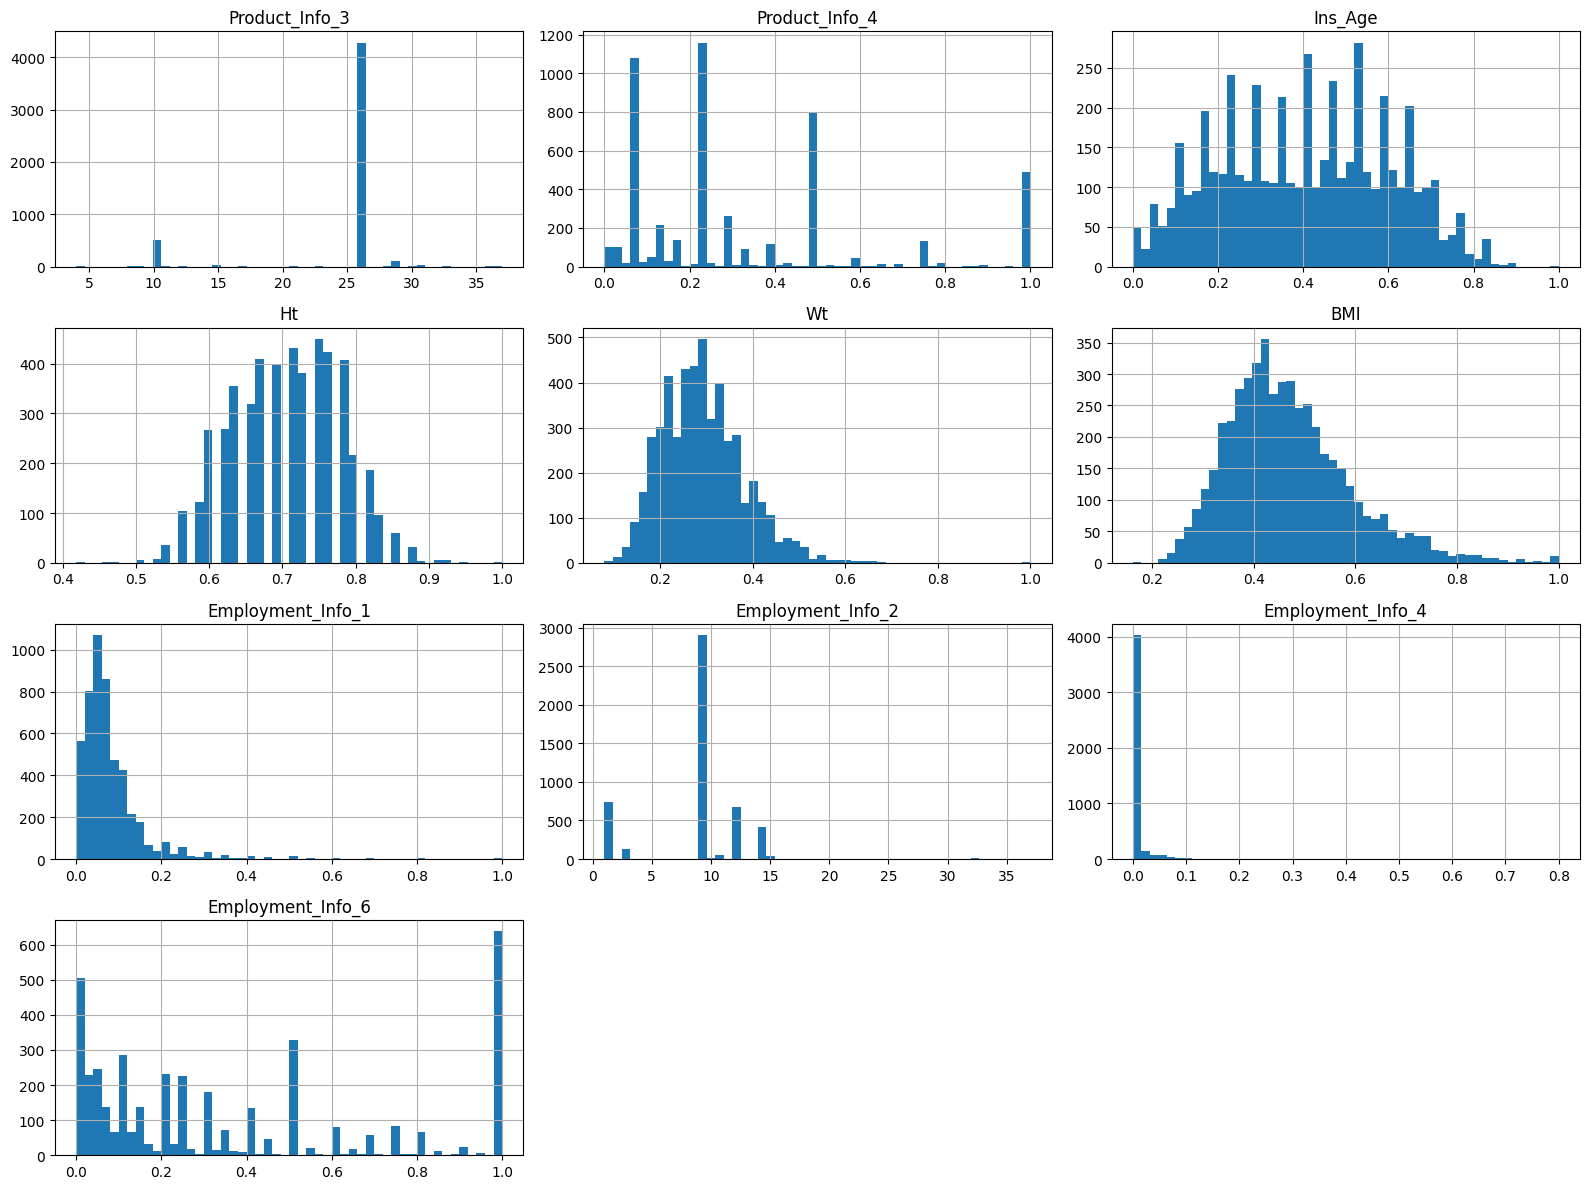

In [27]:

if plt is None:
    raise ImportError("matplotlib is required for plotting. Install it or skip this cell.")
if not continuous_like:
    raise ValueError("No continuous-like features available for plotting.")

plot_cols = continuous_like[:10]
plot_sample = train.sample(min(5000, len(train)), random_state=0)

print(f"Histogram sample size: {len(plot_sample)} | columns: {plot_cols}")
plot_sample[plot_cols].hist(bins=50, figsize=(16, 12))
plt.tight_layout()


Boxplot sample size: 5000 | columns: ['Product_Info_3', 'Product_Info_4', 'Ins_Age', 'Ht', 'Wt', 'BMI', 'Employment_Info_1', 'Employment_Info_2', 'Employment_Info_4', 'Employment_Info_6']
Scatter-matrix sample size: 2500 | columns: ['Product_Info_3', 'Product_Info_4', 'Ins_Age', 'Ht', 'Wt', 'Response']


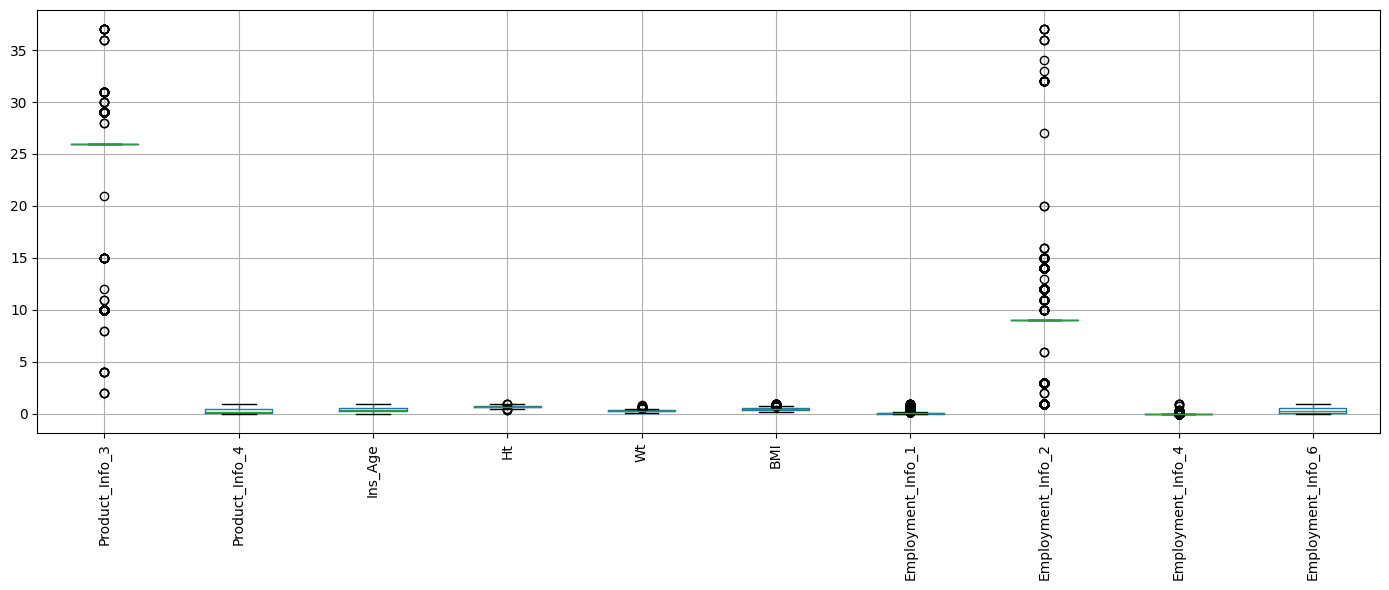

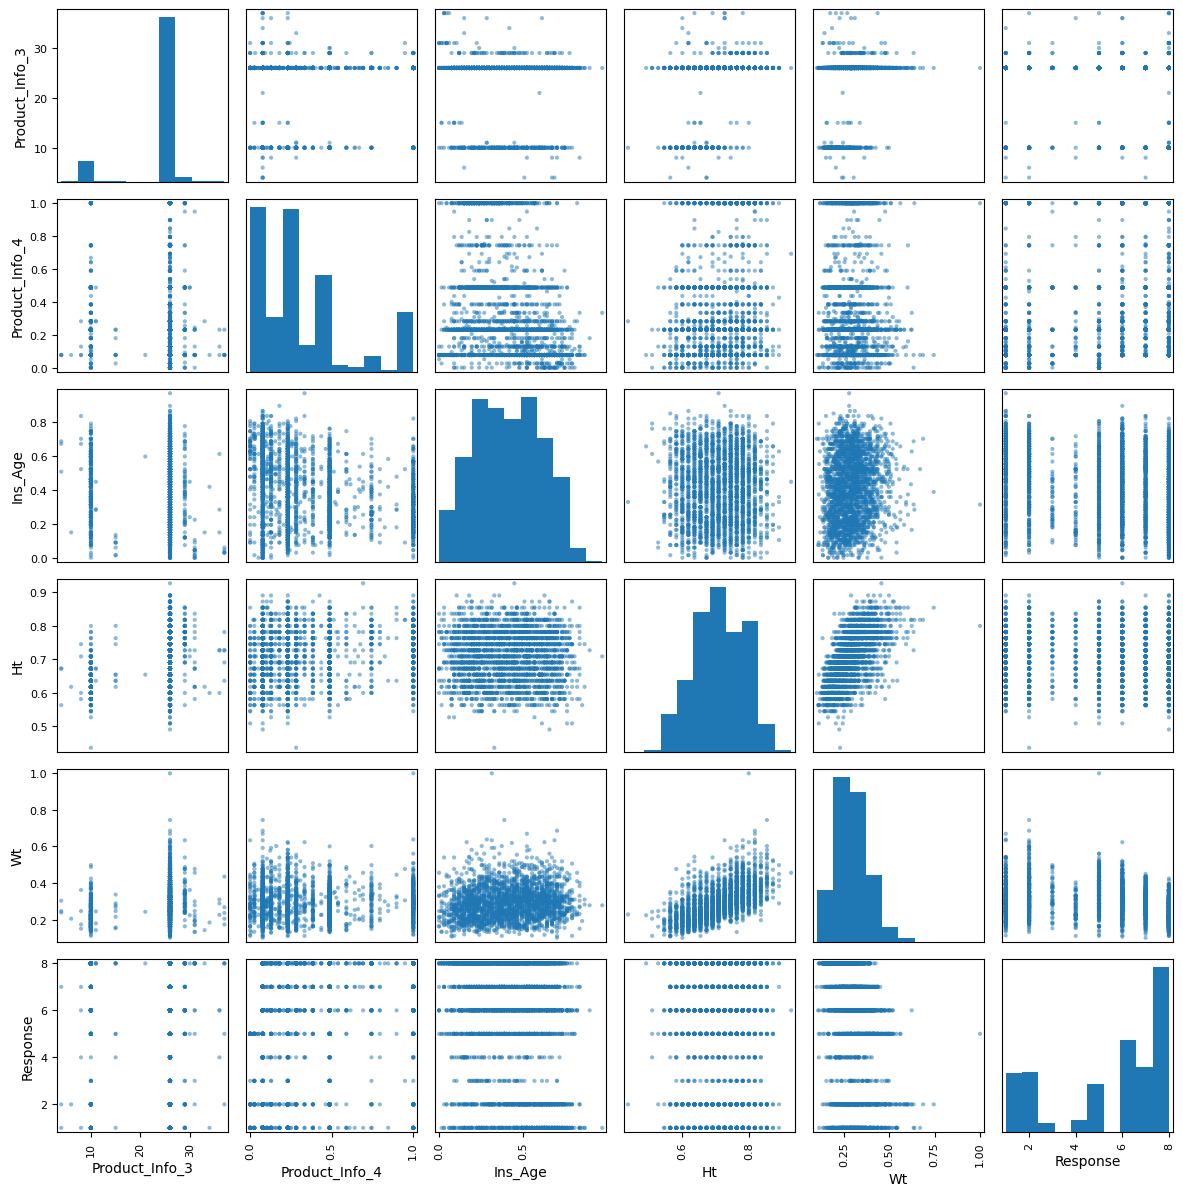

In [28]:

if plt is None:
    raise ImportError("matplotlib is required for plotting. Install it or skip this cell.")
if not continuous_like:
    raise ValueError("No continuous-like features available for plotting.")

box_cols = continuous_like[:10]
plot_sample = train.sample(min(5000, len(train)), random_state=1)
print(f"Boxplot sample size: {len(plot_sample)} | columns: {box_cols}")
plot_sample[box_cols].boxplot(rot=90, figsize=(14, 6))
plt.tight_layout()

scatter_cols = continuous_like[:5]
scatter_sample = train.sample(min(2500, len(train)), random_state=2)
print(f"Scatter-matrix sample size: {len(scatter_sample)} | columns: {scatter_cols + [TARGET]}")
pd.plotting.scatter_matrix(scatter_sample[scatter_cols + [TARGET]], figsize=(12, 12))
plt.tight_layout()
